<a href="https://colab.research.google.com/github/deaasanta/MachineLearning/blob/main/Week_8_Assignment_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nama: Dea Santa Nainggolan
# NIM: 4222301022
# Kelas: Pagi A

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [ ]:
df = pd.read_csv('/content/sample_data/berat_tinggi.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

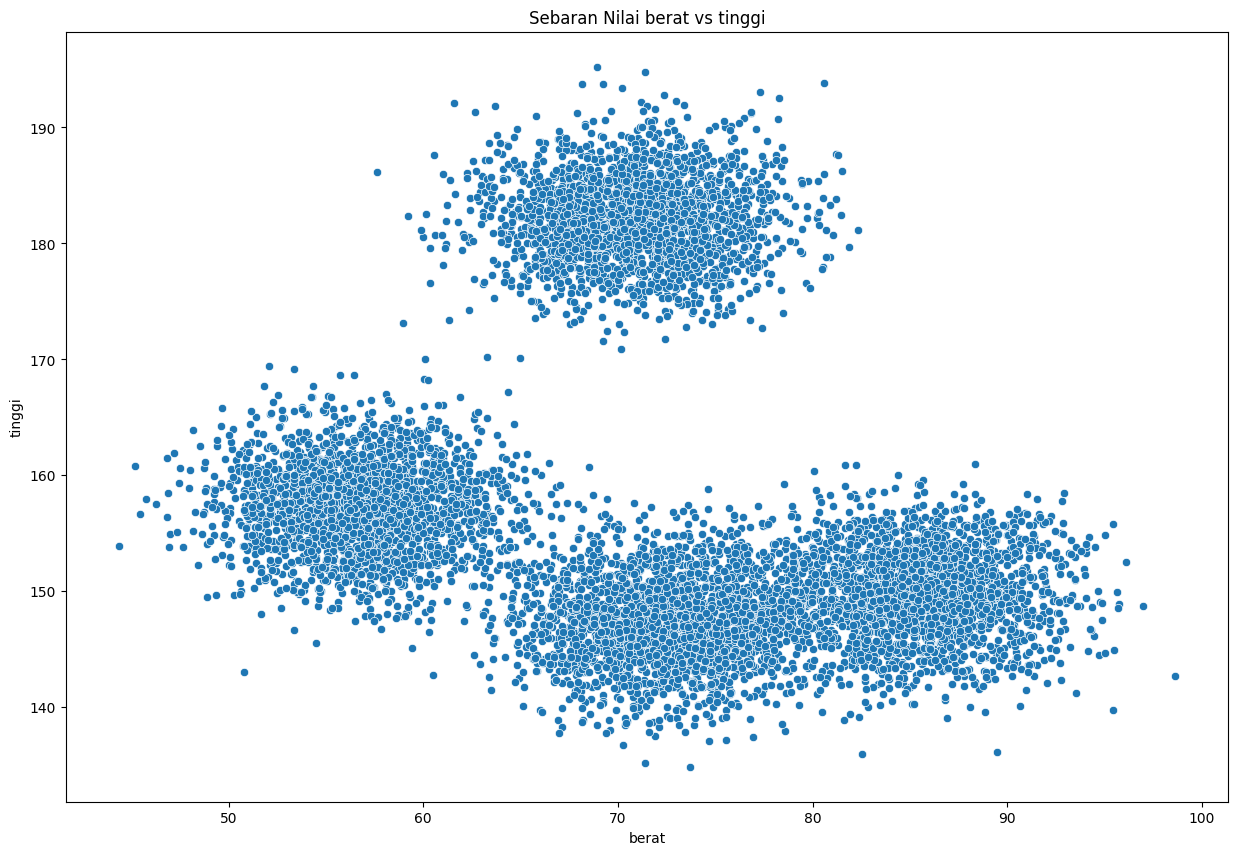

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [ ]:
df.describe()

,tinggi,berat
count,8888.000000,8888.000000
mean,159.125498,71.365302
std,14.258305,10.729120
min,134.881305,44.344643
25%,148.522565,63.557079
50%,153.805704,71.748643
75%,170.365514,79.003827
max,195.232920,98.644868


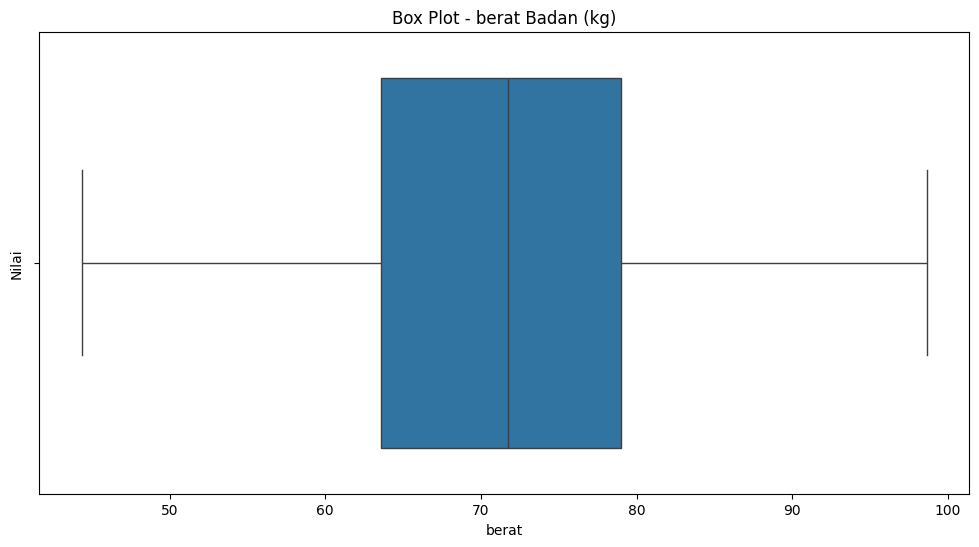

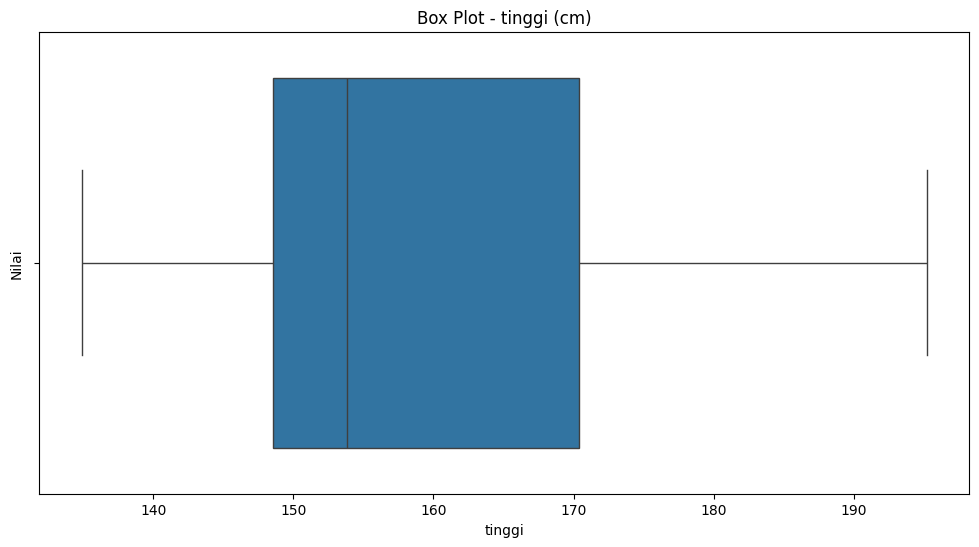

In [ ]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

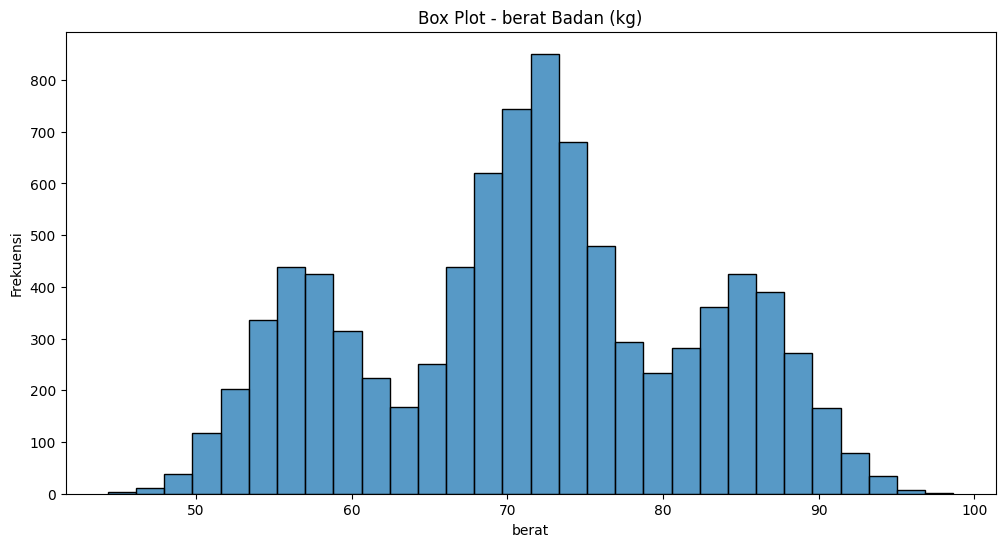

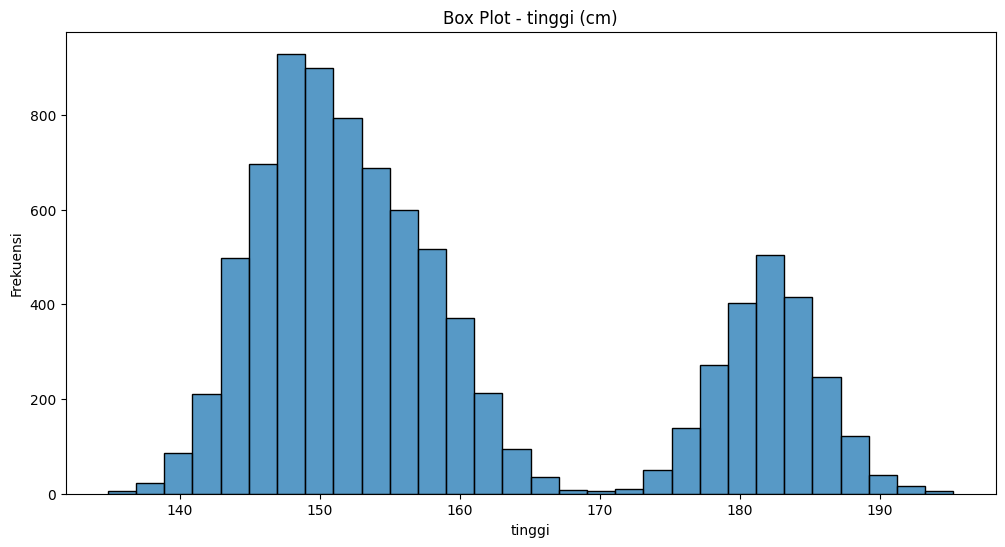

In [ ]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [ ]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 8888
Dataframe dimension after duplication drop 8888


dari hasil running program diatas, tidak ada data yg duplikat

In [ ]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [ ]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,berat,tinggi
count,8.888000e+03,8.888000e+03
mean,3.785351e-16,-1.893375e-15
std,1.000056e+00,1.000056e+00
min,-2.518583e+00,-1.700451e+00
25%,-7.278008e-01,-7.436739e-01
50%,3.573103e-02,-3.731224e-01
75%,7.119833e-01,7.883579e-01
max,2.542716e+00,2.532521e+00


In [ ]:
X_std

array([[-1.2118229 , -0.07092171],
       [-1.75281897,  0.08546572],
       [-0.87900786,  0.16556767],
       ...,
       [-0.89346332, -0.02015625],
       [-1.6141688 , -0.17762697],
       [ 1.40264032, -0.3111536 ]])

In [ ]:
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

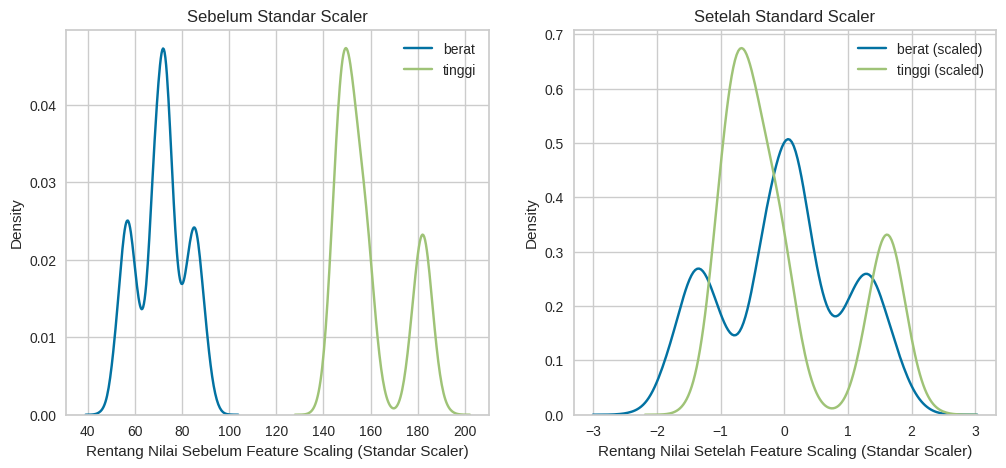

In [ ]:
# Cek grafik sebelum dan setelah scaling
# Kita lihat distribusi dari variabel sebelum Standard Scaler dan setelah Standard Scaler

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standard Scaler (isi di bawah ini)
ax1.set_title('Sebelum Standar Scaler')
sns.kdeplot(df['berat'], ax=ax1, label='berat')
sns.kdeplot(df['tinggi'], ax=ax1, label='tinggi')

# Plot distribusi setelah Standard Scaler (isi di bawah ini)
ax2.set_title('Setelah Standard Scaler')
sns.kdeplot(df_scalling['berat'], ax=ax2, label='berat (scaled)')
sns.kdeplot(df_scalling['tinggi'], ax=ax2, label='tinggi (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Feature Scaling (Standar Scaler)')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scaling (Standar Scaler)')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum dilakukan *feature scaling*, variabel **berat** dan **tinggi** memiliki rentang nilai yang berbeda.
2. Perbedaan rentang nilai dapat menyebabkan salah satu fitur lebih dominan dalam proses analisis atau pelatihan model.
3. Setelah menggunakan **Standard Scaler**, distribusi data menjadi lebih seimbang dan terstandarisasi.
4. Nilai data setelah scaling terpusat di sekitar rata-rata dengan skala yang seragam.
5. Proses scaling membantu meningkatkan performa algoritma machine learning.
6. Feature scaling juga membuat proses pelatihan model menjadi lebih cepat dan stabil.
7. Dengan skala fitur yang sama, model dapat melakukan analisis data dengan lebih optimal dan akurat.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

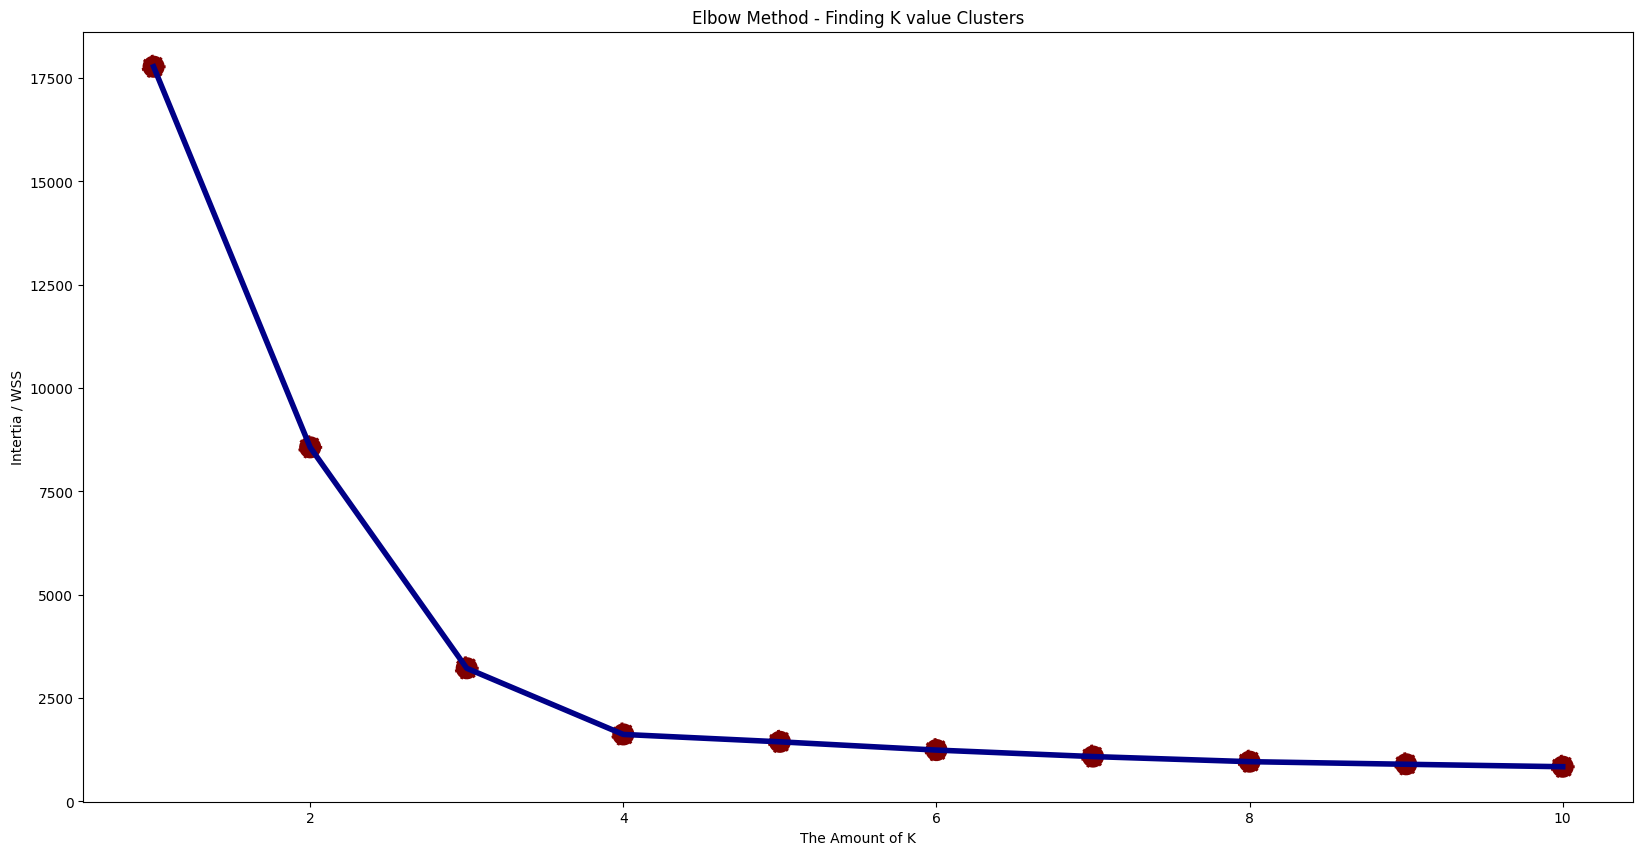

In [ ]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [ ]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [ ]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [ ]:
df

,tinggi,berat,deskripsi,cluster_elbow
0,158.114332,58.364240,Normal,0
1,160.344026,52.560155,Normal,0
2,161.486080,61.934852,Normal,0
3,182.459297,69.042108,Slim,2
4,184.462584,71.341076,Slim,2
...,...,...,...,...
8883,177.296550,74.905033,Slim,2
8884,151.605026,81.084183,Obese,3
8885,158.838120,61.779766,Normal,0
8886,156.592981,54.047666,Normal,0


<Axes: xlabel='berat', ylabel='tinggi'>

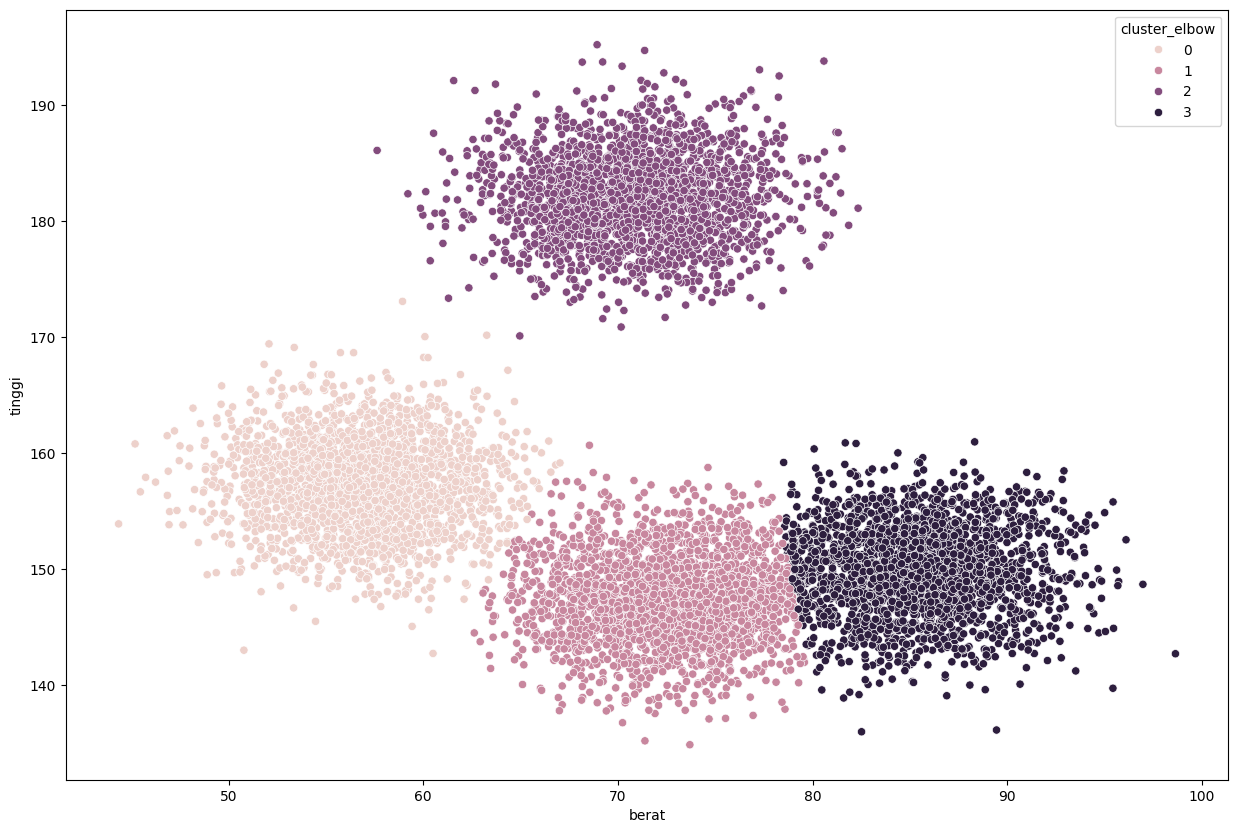

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

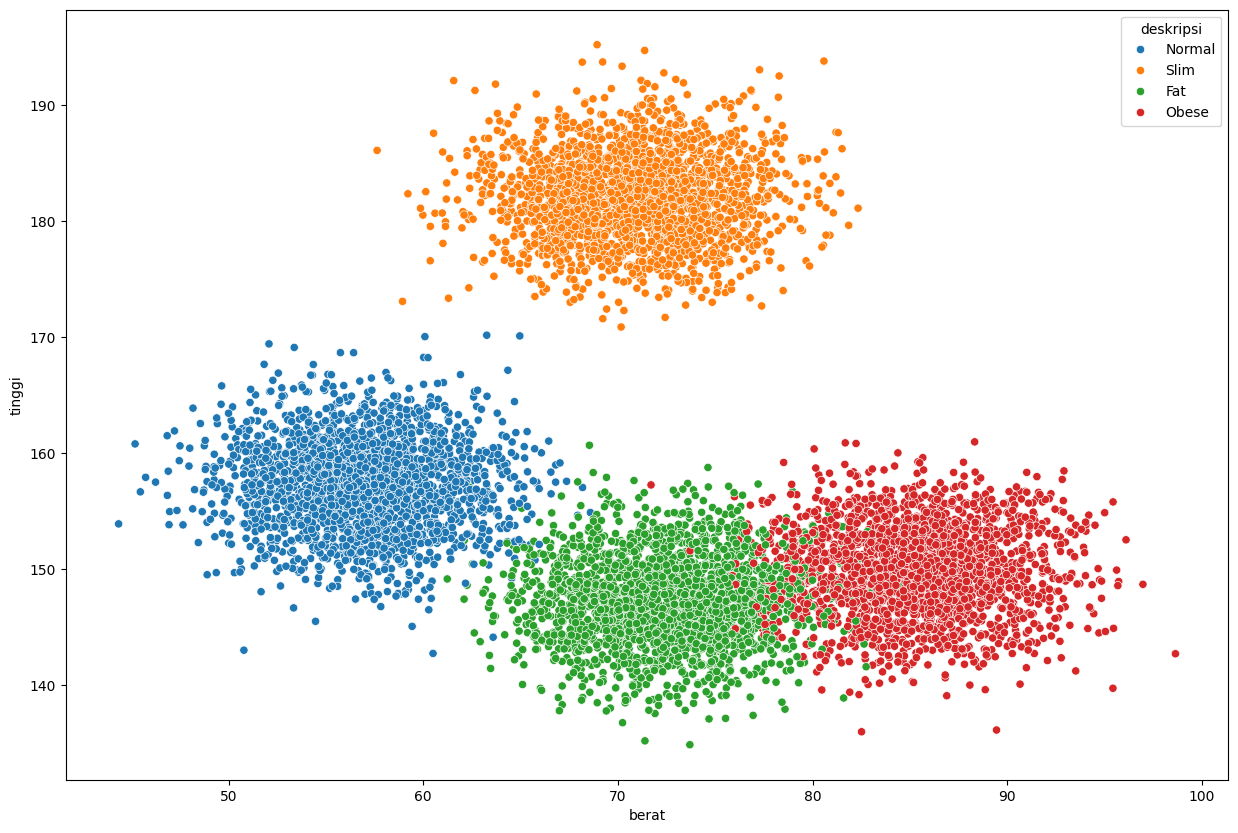

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [ ]:
!pip install yellowbrick

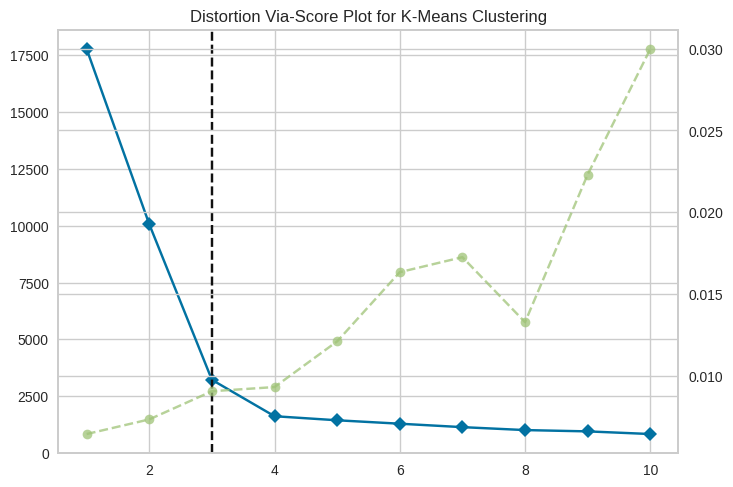

In [ ]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [ ]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [ ]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [ ]:
df

,tinggi,berat,deskripsi,cluster_elbow,cluster_via
0,158.114332,58.364240,Normal,0,0
1,160.344026,52.560155,Normal,0,0
2,161.486080,61.934852,Normal,0,0
3,182.459297,69.042108,Slim,2,2
4,184.462584,71.341076,Slim,2,2
...,...,...,...,...,...
8883,177.296550,74.905033,Slim,2,2
8884,151.605026,81.084183,Obese,3,1
8885,158.838120,61.779766,Normal,0,0
8886,156.592981,54.047666,Normal,0,0


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

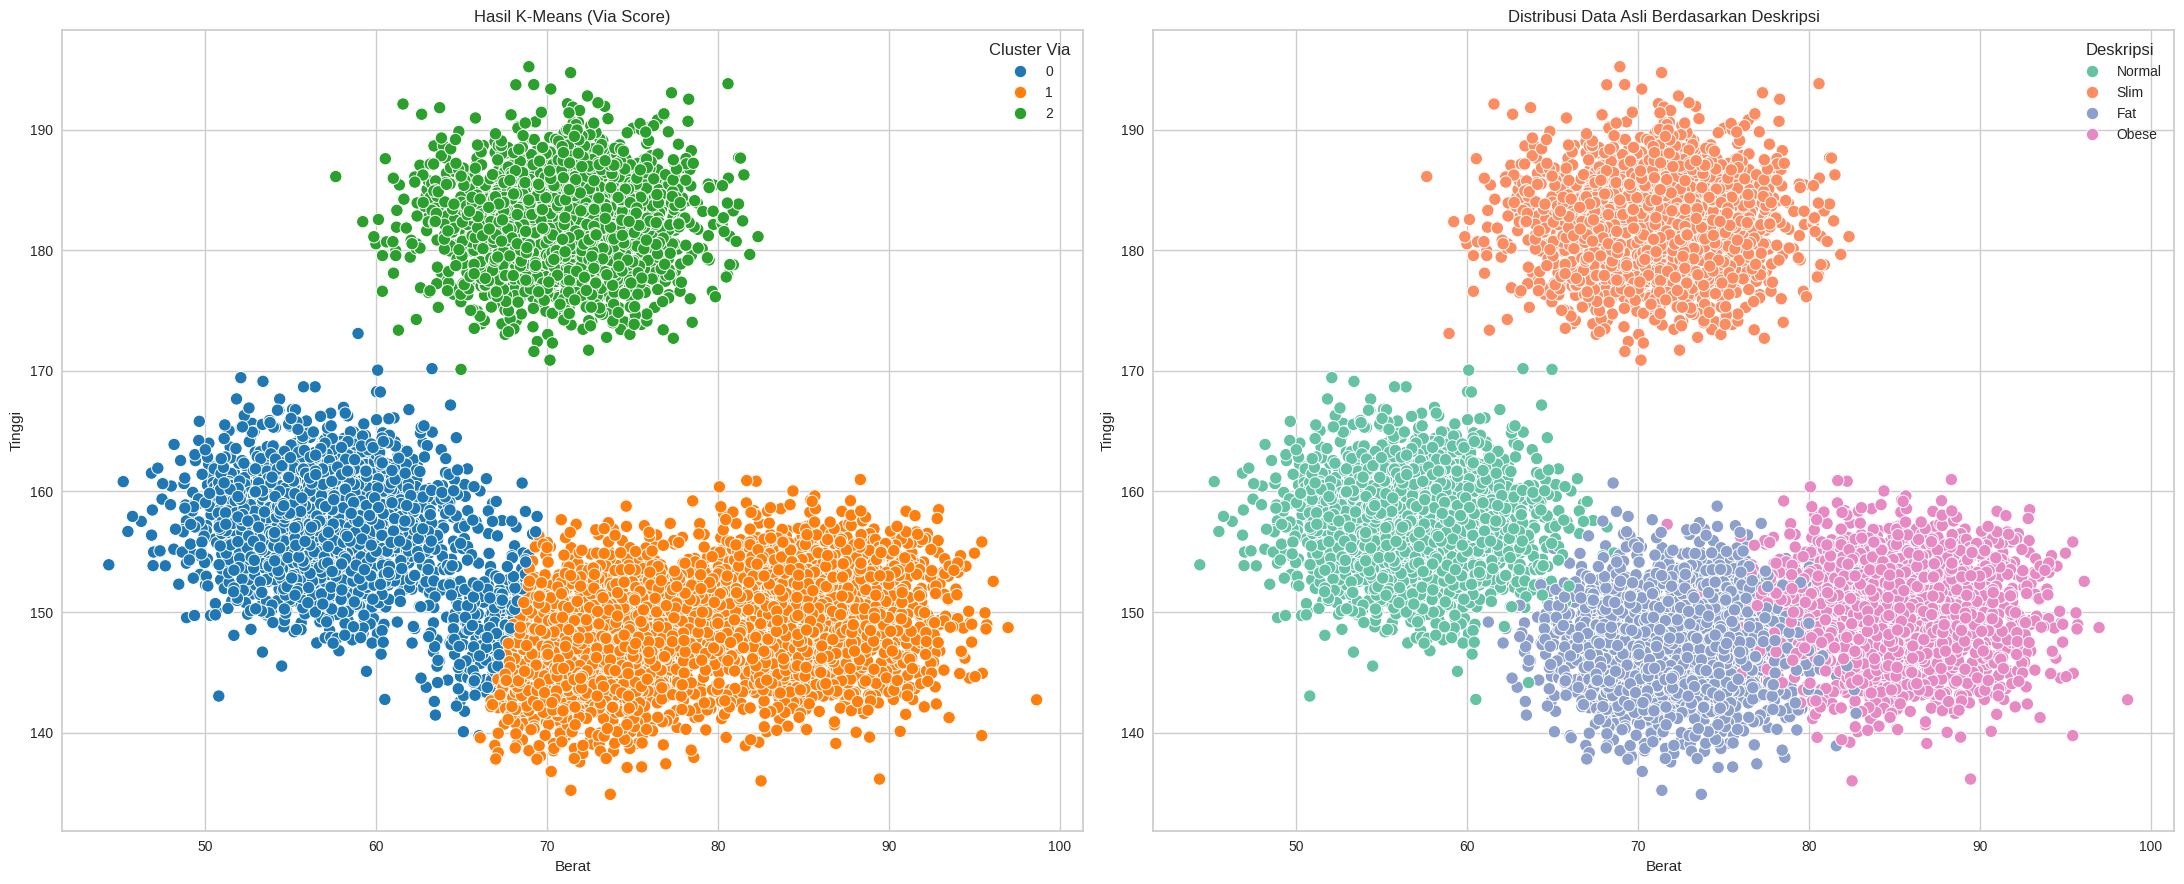

In [ ]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli
fig, axes = plt.subplots(ncols=2, figsize=(22, 9))

sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='cluster_via',
    palette='tab10',
    s=80,
    ax=axes[0]
)
axes[0].set_title('Hasil K-Means (Via Score)')
axes[0].set_xlabel('Berat')
axes[0].set_ylabel('Tinggi')
axes[0].legend(title='Cluster Via', loc='best')

sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='deskripsi',
    palette='Set2',
    s=80,
    ax=axes[1]
)
axes[1].set_title('Distribusi Data Asli Berdasarkan Deskripsi')
axes[1].set_xlabel('Berat')
axes[1].set_ylabel('Tinggi')
axes[1].legend(title='Deskripsi', loc='best')

plt.tight_layout()
plt.show()

### Bandingkan dengan label anotator

deskripsi     Fat  Normal  Obese  Slim
cluster_via                           
0             239    2221      0     1
1            1983       0   2222     0
2               0       1      0  2221


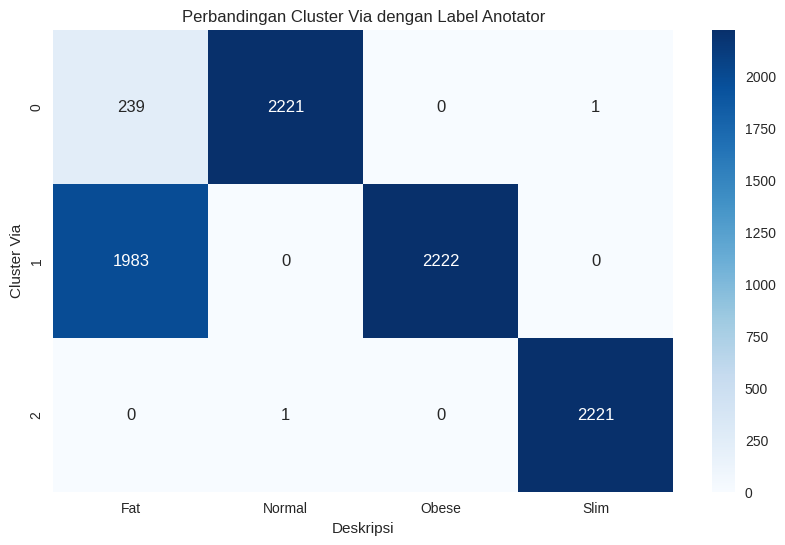

In [ ]:
# Bandingkan dengan label anotator
ct = pd.crosstab(df['cluster_via'], df['deskripsi'])
print(ct)

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Perbandingan Cluster Via dengan Label Anotator')
plt.ylabel('Cluster Via')
plt.xlabel('Deskripsi')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Hasil evaluasi menunjukkan bahwa algoritma **K-Means** berhasil mengelompokkan data ke dalam beberapa cluster berdasarkan karakteristik data.
2. **Cluster 0** didominasi oleh label **Normal** dengan jumlah data sebanyak **2221**, sehingga cluster ini dapat merepresentasikan kategori Normal.
3. **Cluster 1** banyak berisi label **Fat** sebanyak **1983** dan label **Obese** sebanyak **2222**, sehingga cluster ini cenderung merepresentasikan kategori dengan berat badan berlebih.
4. **Cluster 2** didominasi oleh label **Slim** sebanyak **2221**, sehingga cluster ini merepresentasikan kategori tubuh kurus.
5. Terdapat beberapa data yang tidak sesuai dengan mayoritas cluster, misalnya nilai kecil pada kategori lain, namun jumlahnya sangat sedikit sehingga tidak terlalu mempengaruhi hasil keseluruhan.
6. Heatmap menunjukkan warna yang lebih gelap pada jumlah data terbesar, menandakan bahwa sebagian besar data berhasil dikelompokkan dengan baik oleh model K-Means.
7. Secara keseluruhan, hasil clustering menunjukkan bahwa metode K-Means mampu memisahkan data berdasarkan pola kategori tubuh dengan cukup baik dan akurat.


### Thank you :)